<a href="https://colab.research.google.com/github/misun0314/AI-Python/blob/main/%ED%8C%8C%EC%9D%B4%EC%8D%AC_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EB%A7%9B%EB%B3%B4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [자동화] 반복적인 엑셀 취합 도구
* 매일 아침 여러 부서에서 오는 현황 보고서를 클릭 한 번으로 통합하고 요약표 만들기.

In [ ]:
import pandas as pd
import glob

# 1. 특정 폴더 내의 모든 엑셀 파일 목록 가져오기
files = glob.glob("납기현황_*.xlsx") # 예: 납기현황_A사.xlsx, 납기현황_B사.xlsx

all_data = []

# 2. 반복문으로 파일 읽어서 리스트에 담기
for file in files:
    df = pd.read_excel(file)
    df['업체명'] = file.split('_')[1].replace('.xlsx', '') # 파일명에서 업체명 추출
    all_data.append(df)

# 3. 하나로 합치고 엑셀로 저장
total_df = pd.concat(all_data, ignore_index=True)
total_df.to_excel("통합_납기현황_리포트.xlsx", index=False)

print("✅ 모든 엑셀 파일이 하나로 합쳐졌습니다!")

✅ 모든 엑셀 파일이 하나로 합쳐졌습니다!


#[관리] 자재 납기 지연 알람 시스템
* 납기일이 지난 자재들만 골라내어 '긴급' 리스트를 만들고 엑셀로 내보내기.

In [ ]:
import pandas as pd
from datetime import datetime

# 1. 자재 리스트 불러오기
df = pd.read_excel("자재리스트.xlsx")

# 2. 날짜 형식으로 변환 및 오늘 날짜 설정
df['납기예정일'] = pd.to_datetime(df['납기예정일'])
today = datetime.now()

# 3. 지연된 항목만 필터링 (오늘보다 이전 날짜이면서 미입고인 경우)
delayed = df[(df['납기예정일'] < today) & (df['입고여부'] == 'N')]

# 4. 결과 출력 및 저장
print(f"⚠️ 현재 지연된 자재는 총 {len(delayed)}건입니다.")
delayed.to_excel("긴급_지연자재_명단.xlsx")

⚠️ 현재 지연된 자재는 총 3건입니다.


#[분석] 우리 공장 병목 구간 찾기
* 각 공정별 소요 시간 데이터를 분석해 가장 오래 걸리는 공정(Bottle-neck)을 시각적으로 찾아내기.

✅ 데이터를 성공적으로 불러왔습니다.


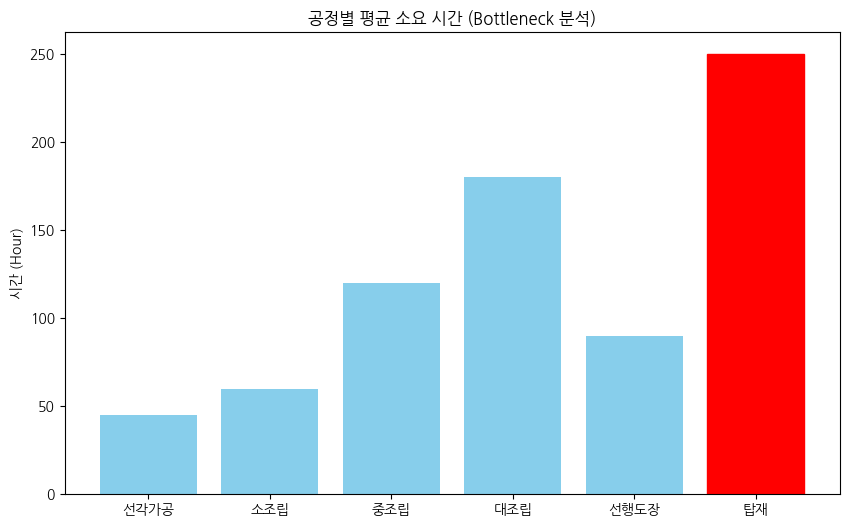

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정 (윈도우 기준)
plt.rc('font', family='NanumGothic')

# 1. 엑셀 파일로부터 학습 데이터 불러오기
try:
    # 엑셀 파일을 읽어 df(데이터프레임) 변수에 저장
    df = pd.read_excel("공정데이터.xlsx")
    print("✅ 데이터를 성공적으로 불러왔습니다.")
    #print(df.head()) # 데이터 상단 5줄 출력하여 확인
except FileNotFoundError:
    print("❌ 파일이 없습니다. '공정데이터.xlsx' 파일명을 확인해주세요.")

# 2. 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(df['공정단계'], df['실제시간(h)'], color='skyblue')
bars[5].set_color('red') # 가장 오래 걸리는 '탑재' 공정 강조

plt.title("공정별 평균 소요 시간 (Bottleneck 분석)")
plt.ylabel("시간 (Hour)")
plt.show()

#[예측] 선박 주요 치수 기반 중량 예측
* L, B, D(선박 제원)를 입력하면 예상되는 총 강재 중량을 자동으로 계산해주는 프로그램.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. 엑셀 파일로부터 학습 데이터 불러오기
try:
    # 엑셀 파일을 읽어 df(데이터프레임) 변수에 저장
    df = pd.read_excel("선박데이터_학습용.xlsx")
    print("✅ 데이터를 성공적으로 불러왔습니다.")
   # print(df.head()) # 데이터 상단 5줄 출력하여 확인
except FileNotFoundError:
    print("❌ 파일이 없습니다. '선박데이터_학습용.xlsx' 파일명을 확인해주세요.")

# 2. AI 모델 학습을 위한 입력 데이터(X)와 정답 데이터(y) 분리
# 입력값(X): 길이(L), 폭(B), 깊이(D)
# 결과값(y): 강재중량(Weight)
X = df[['길이(L)', '폭(B)', '깊이(D)']]
y = df['강재중량(Weight)']

# 3. 선형 회귀(Linear Regression) 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)
print("\n🤖 AI 모델 학습 완료!")

# 4. 새로운 선박 제원을 입력하여 중량 예측하기
# 예: 길이 220m, 폭 35m, 깊이 21m인 선박의 중량은?
# 경고를 제거하기 위해 predict 입력도 DataFrame 형태로 변경
new_ship_specs_data = [[220, 35, 21]]
new_ship_specs_df = pd.DataFrame(new_ship_specs_data, columns=X.columns) # X의 컬럼명 사용
predicted_weight = model.predict(new_ship_specs_df)

print("-" * 30)
print(f"🚢 입력 제원: L={new_ship_specs_data[0][0]}, B={new_ship_specs_data[0][1]}, D={new_ship_specs_data[0][2]}")
print(f"⚖️ 예측된 강재 중량: 약 {predicted_weight[0]:.2f} 톤")
print("-" * 30)

# 5. (추가) 예측 결과를 엑셀로 저장하기
# 학습 데이터 뒤에 예측값을 붙여서 확인해보고 싶을 때 사용
df['AI_예측중량'] = model.predict(X)
df.to_excel("선박중량_예측결과_리포트.xlsx", index=False)
print("📊 전체 데이터에 대한 예측 리포트가 저장되었습니다.")

✅ 데이터를 성공적으로 불러왔습니다.

🤖 AI 모델 학습 완료!
------------------------------
🚢 입력 제원: L=220, B=35, D=21
⚖️ 예측된 강재 중량: 약 11489.71 톤
------------------------------
📊 전체 데이터에 대한 예측 리포트가 저장되었습니다.
